In [1]:
import os

import pandas as pd

import numpy as np
import pywt
from scipy.signal import  savgol_filter

from scipy import signal
from scipy import stats
from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
# ##################################
from matplotlib import pyplot as plt
from matplotlib import font_manager, rcParams

font_path = "../wqy-zenhei.ttc"
font_manager.fontManager.addfont(font_path)

# 2. 获取字体名称
font_prop = font_manager.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print("Loaded font name:", font_name)

# 3. 设置为全局字体
rcParams['font.sans-serif'] = [font_name]
rcParams['axes.unicode_minus'] = False
# #######################################


# 0.1s采集一次，25600hz，每次采集2560个点，2000转每分钟
FS = 25600


Loaded font name: WenQuanYi Zen Hei


In [2]:
def compute_psd(x, fs=FS, nperseg=None): 
    """
    计算功率谱密度,振动能量主要分布在哪些频率上
    freqs  # 频率轴（Hz）
    psd    # 每个频率点的功率密度
    """
    if nperseg is None: 
        nperseg = min(len(x), 4096) 
    freqs, psd = signal.welch(x - np.mean(x), fs=fs, window='hann', nperseg=nperseg) 
    return freqs, psd

<Figure size 640x480 with 0 Axes>

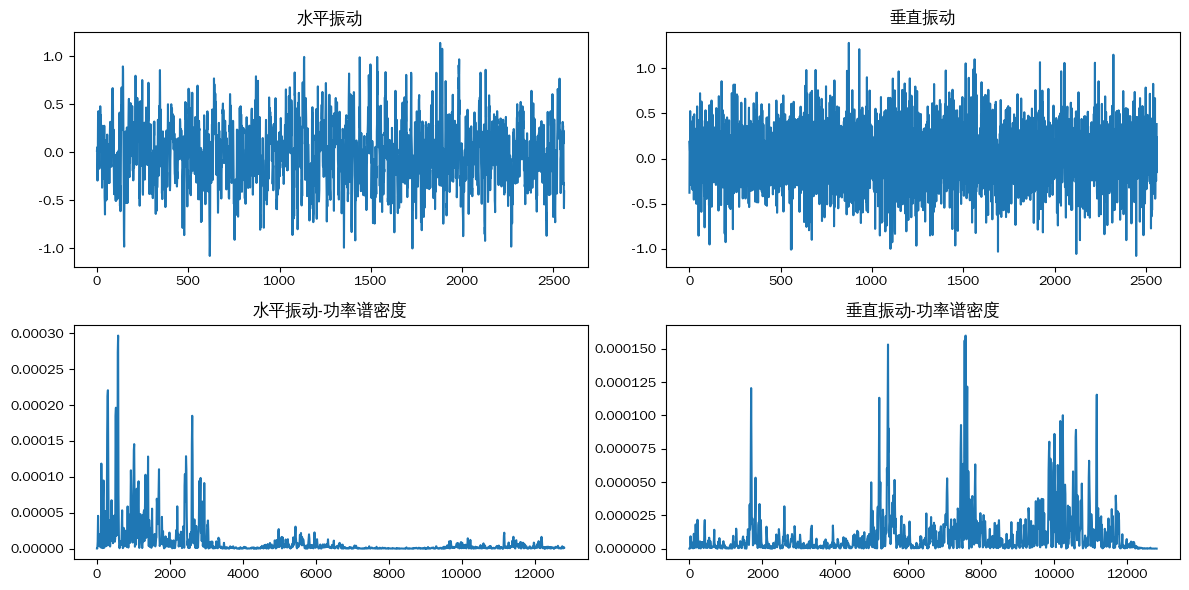

In [3]:
def view_sample(folder):
    acc_files = sorted([os.path.join(folder, file) for file in os.listdir(folder) if file.startswith('acc') and file.endswith('.csv')])
    df = pd.read_csv(random.choice(acc_files), header=None)
    h_X = df.values[:, 4]
    v_X = df.values[:, 5]
    h_X_freqs, h_X_psd = compute_psd(df.values[:, 4])
    v_X_freqs, v_X_psd = compute_psd(df.values[:, 5])
    
    plt.figure()
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes = axes.flatten()
    axes[0].set_title('水平振动')
    axes[0].plot(h_X)
    
    axes[1].set_title('垂直振动')
    axes[1].plot(v_X)
    
    axes[2].set_title('水平振动-功率谱密度')
    axes[2].plot( h_X_freqs, h_X_psd )
    axes[3].set_title('垂直振动-功率谱密度')
    axes[3].plot(v_X_freqs, v_X_psd)
    plt.tight_layout()
    plt.show()
view_sample("./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing1_1")
    


In [4]:
# 可提升点
# 目前都是统计型的，对于轴承，我们通常知道其几何尺寸，可以计算出 BPFO (外圈), BPFI (内圈), FTF (保持架), BSF (滚动体) 的特征频率。

In [5]:
def extract_time_features(x):
    rms = np.sqrt(np.mean(x**2))
    peak = np.max(np.abs(x))

    return {
        "rms": rms, # 均方根（有效值），反映信号的能量水平
        "std": np.std(x), # 标准差，反映信号的离散程度
        "mean": np.mean(x), # 均值，反映信号的直流分量
        "kurtosis": stats.kurtosis(x), # 峰度，衡量信号分布的陡峭程度
        "skewness": stats.skew(x), # 偏度，衡量信号分布的不对称性
        "peak2peak": np.ptp(x), # 峰峰值，信号最大值与最小值的差
        "crest_factor": peak / (rms + 1e-12),  # 波峰因子，衡量峰值相对有效值的突出程度
        "impulse_factor": peak / (np.mean(np.abs(x)) + 1e-12), # 脉冲因子，对冲击类信号敏感，常用于故障检测
        "clearance_factor": peak / ((np.mean(np.sqrt(np.abs(x)))**2) + 1e-12), # 裕度因子，同样对冲击信号敏感，是故障诊断的重要指标
    }


In [6]:
def extract_psd_shape_features(x, fs, n_bins=10):
    freqs, psd = compute_psd(x, fs)
    psd_energy = psd.sum() + 1e-12 # 频谱总能量
    psd_norm = psd / psd_energy

    # 频谱形态
    centroid = np.sum(freqs * psd_norm)
    bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * psd_norm))
    entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))
    flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)

    feats = {
        "psd_energy": psd_energy, # 频谱总能量，反映信号的整体能量水平
        "spectral_entropy": entropy, # 频谱熵，衡量能量分布的均匀性
        "spectral_centroid": centroid, # 频谱重心（质心），代表能量集中的频率位置
        "spectral_bandwidth": bandwidth, # 频谱带宽，反映能量在频率轴上的分散程度
        "spectral_flatness": flatness, # 频谱平坦度，衡量频谱接近白噪声的程度
    }

    # 比例 band（低 / 中 / 高）
    fmax = freqs[-1]
    feats.update({
        "psd_ratio_low": psd[freqs < 0.2*fmax].sum() / psd_energy,
        "psd_ratio_mid": psd[(freqs >= 0.2*fmax) & (freqs < 0.5*fmax)].sum() / psd_energy,
        "psd_ratio_high": psd[freqs >= 0.5*fmax].sum() / psd_energy,
    })

    # 等频 bin
    bins = np.linspace(0, fmax, n_bins+1)
    for i in range(n_bins):
        idx = (freqs >= bins[i]) & (freqs < bins[i+1])
        feats[f"psd_bin_energy_{i}"] = psd[idx].sum() / psd_energy

    return feats

In [7]:
def extract_envelope_features(x, fs, n_bins=8):
    analytic = signal.hilbert(x - np.mean(x))
    env = np.abs(analytic)

    env = env - env.mean()
    
    freqs, psd_env = compute_psd(env, fs)
    psd_env = psd_env + 1e-12
    psd_env_norm = psd_env / (psd_env.sum() + 1e-12)

    centroid = np.sum(freqs * psd_env_norm)
    entropy = -np.sum(psd_env_norm * np.log(psd_env_norm + 1e-12))

    feats = {
        "env_rms": np.sqrt(np.mean(env**2)), # 包络信号的均方根，反映包络的能量水平
        "env_kurtosis": stats.kurtosis(env), # 衡量包络分布的陡峭程度
        "env_entropy": entropy, # 包络谱的熵，衡量包络能量分布均匀性
        "env_centroid": centroid, # 包络谱重心，代表包络能量集中的频率位置
    }

    # 包络谱能量分箱
    fmax = freqs[-1]
    bins = np.linspace(0, fmax, n_bins+1)
    for i in range(n_bins):
        idx = (freqs >= bins[i]) & (freqs < bins[i+1])
        feats[f"env_bin_energy_{i}"] = psd_env[idx].sum() / psd_env.sum()

    return feats


In [8]:
def extract_wavelet_features(x):
    x = x - np.mean(x)
    # 小波分解
    coeffs = pywt.wavedec(x, 'db4', level=4)
    # 各层能量
    energies = np.array([np.sum(c**2) for c in coeffs])
    total_energy = np.sum(energies) + 1e-12

    # 高频层（D1 + D2）
    high_energy = energies[-1] + energies[-2]
    high_ratio = high_energy / (total_energy + 1e-12)

    # 小波能量熵（可选，但很有价值）
    energy_norm = energies / (total_energy + 1e-12)
    wavelet_entropy = -np.sum(energy_norm * np.log(energy_norm + 1e-12))

    return {
        "wavelet_energy": total_energy,
        "wavelet_high_ratio": high_ratio,
        "wavelet_entropy": wavelet_entropy
    }

In [9]:

def extract_features(x, fs=25600):
    feats = {}

    # 时域特征
    feats.update(extract_time_features(x))
    # 频域特征
    feats.update(extract_psd_shape_features(x, fs))
    # 包络
    feats.update(extract_envelope_features(x, fs))
    # 小波特征
    feats.update(extract_wavelet_features(x))
    return feats


In [10]:
def process_bearing(folder):
    acc_files = sorted([os.path.join(folder, file) for file in os.listdir(folder) if file.startswith('acc') and file.endswith('.csv')])
    print(f'Processing folder {folder}, found {len(acc_files)} acc files')

    features = []
    for file in acc_files:
        sig = pd.read_csv(file, header=None).to_numpy()[:, 4] # 水平振动
        feat_dict = extract_features(sig, fs=FS)
        features.append(feat_dict)
    features = pd.DataFrame(features)
    return features

In [11]:
df_11 = process_bearing(folder="./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing1_1")
df_12 = process_bearing(folder="./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing1_2")

Processing folder ./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing1_1, found 2803 acc files
Processing folder ./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing1_2, found 871 acc files


In [12]:
def get_healthy_reference(df, window=200, threshold_ratio=3.0, features=('rms',)):
    """
    自动选择健康参考段。
    
    参数：
    - df: 特征 DataFrame
    - window: 用前 window 个点作为健康基线
    - threshold_ratio: 阈值系数（均值 + threshold_ratio * std）
    - features: 用于判定的特征列名元组，例如 ('rms', 'kurtosis')
    
    返回：
    - 健康数据 DataFrame
    """
    # 基线统计
    base_stats = {}
    for feat in features:
        vals = df[feat].values[:window]
        base_stats[feat] = (np.mean(vals), np.std(vals))
    
    # 遍历数据，寻找退化点
    for i in range(window, len(df) - 5):
        exceed_count = 0
        for feat in features:
            mean, std = base_stats[feat]
            limit = mean + threshold_ratio * std
            if np.all(df[feat].values[i:i+5] > limit):
                exceed_count += 1
        # 如果多个特征同时超过阈值，认为进入退化期
        if exceed_count >= max(1, len(features)//2):
            return df.iloc[:i]
    
    # 如果没找到退化点，返回全部数据（更稳妥）
    return df


In [13]:

# HEALTHY_RATIO = 0.3
# n11_h = int(len(df_11) * HEALTHY_RATIO)
# n12_h = int(len(df_12) * HEALTHY_RATIO)

# df_health = pd.concat([
#     df_11.iloc[:n11_h],
#     df_12.iloc[:n12_h]
# ], axis=0)

df_11_h = get_healthy_reference(df_11, window=200)
df_12_h = get_healthy_reference(df_12, window=200)

df_health = pd.concat([df_11_h, df_12_h], axis=0)

def build_health_model(df_health, n_components=0.95):
    scaler = StandardScaler()
    X_h_scaled = scaler.fit_transform(df_health.values)
    pca = PCA(n_components=n_components, random_state=2666)  # 保留95%的方差
    X_h_pca = pca.fit_transform(X_h_scaled)

    mu = X_h_pca.mean(axis=0)
    inv_cov = np.linalg.inv(np.cov(X_h_pca, rowvar=False) + 1e-6*np.eye(X_h_pca.shape[1])) # 加微小扰动防止奇异矩阵

    md_h = np.array([
        mahalanobis(x, mu, inv_cov)
        for x in X_h_pca
    ])

    md_h_mean = md_h.mean()
    return scaler, pca, mu, inv_cov, md_h_mean
scaler, pca, mu, inv_cov,md_h_mean = build_health_model(df_health=df_health, n_components=0.95)

In [14]:

def compute_pca_md_hi(df, scaler, pca, mu_pca, cov_inv_pca, sensitivity=0.05):
    X = scaler.transform(df.values)
    X_proj = pca.transform(X)
    md = np.array([mahalanobis(x, mu_pca, cov_inv_pca) for x in X_proj])
    
    deviation = np.maximum(0, md - md_h_mean)
    hi = np.exp(-sensitivity * deviation)
    # hi = 1 - md / md.max()
    hi = np.clip(hi, 0, 1)
    hi = savgol_filter(hi, 21, 3)
    return hi, md

In [15]:
hi_11, md_11 = compute_pca_md_hi(df_11, scaler, pca, mu, inv_cov)
hi_12, md_12 = compute_pca_md_hi(df_12, scaler, pca, mu, inv_cov)

In [16]:
df3 =  process_bearing(folder="./phm-ieee-2012-data-challenge-dataset-master/Test_set/Bearing1_3")

hi_13, md_13 = compute_pca_md_hi(df3, scaler, pca, mu, inv_cov)


Processing folder ./phm-ieee-2012-data-challenge-dataset-master/Test_set/Bearing1_3, found 1802 acc files


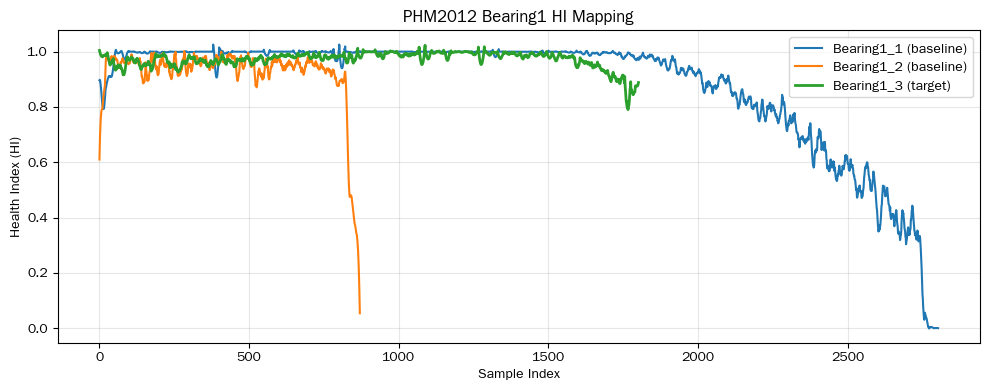

In [17]:

# --------------------------------
# 5. 可视化
# --------------------------------
plt.figure(figsize=(10, 4))
plt.plot(hi_11, label="Bearing1_1 (baseline)")
plt.plot(hi_12, label="Bearing1_2 (baseline)")
plt.plot(hi_13, label="Bearing1_3 (target)", linewidth=2)
plt.xlabel("Sample Index")
plt.ylabel("Health Index (HI)")
plt.title("PHM2012 Bearing1 HI Mapping")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Processing folder ./phm-ieee-2012-data-challenge-dataset-master/Test_set/Bearing1_4, found 1139 acc files


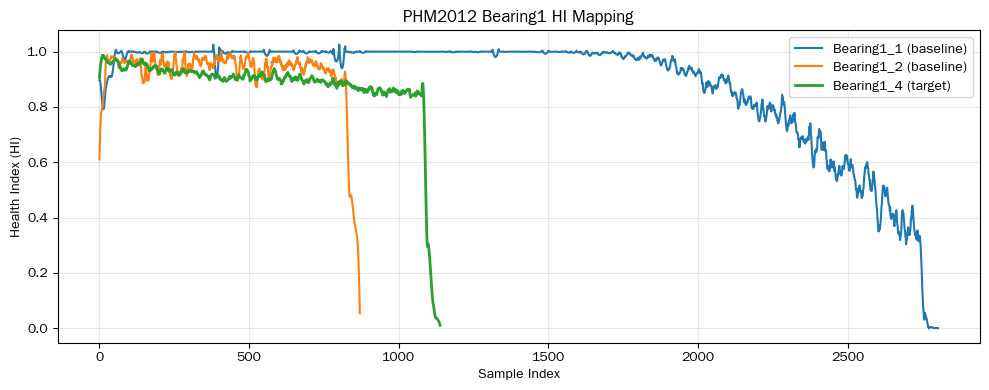

In [18]:
df4 =  process_bearing(folder="./phm-ieee-2012-data-challenge-dataset-master/Test_set/Bearing1_4")

hi_14, md_14 = compute_pca_md_hi(df4, scaler, pca, mu, inv_cov)

# --------------------------------
# 5. 可视化
# --------------------------------
plt.figure(figsize=(10, 4))
plt.plot(hi_11, label="Bearing1_1 (baseline)")
plt.plot(hi_12, label="Bearing1_2 (baseline)")
plt.plot(hi_14, label="Bearing1_4 (target)", linewidth=2)
plt.xlabel("Sample Index")
plt.ylabel("Health Index (HI)")
plt.title("PHM2012 Bearing1 HI Mapping")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
df_21 = process_bearing(folder="./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing2_1")
df_22 = process_bearing(folder="./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing2_2")

df_21_h = get_healthy_reference(df_21, window=200)
df_22_h = get_healthy_reference(df_22, window=200)

df_health = pd.concat([df_21_h, df_22_h], axis=0)

scaler, pca, mu, inv_cov,md_h_mean = build_health_model(df_health=df_health, n_components=0.95)


Processing folder ./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing2_1, found 911 acc files
Processing folder ./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing2_2, found 797 acc files


Processing folder ./phm-ieee-2012-data-challenge-dataset-master/Test_set/Bearing2_7, found 172 acc files


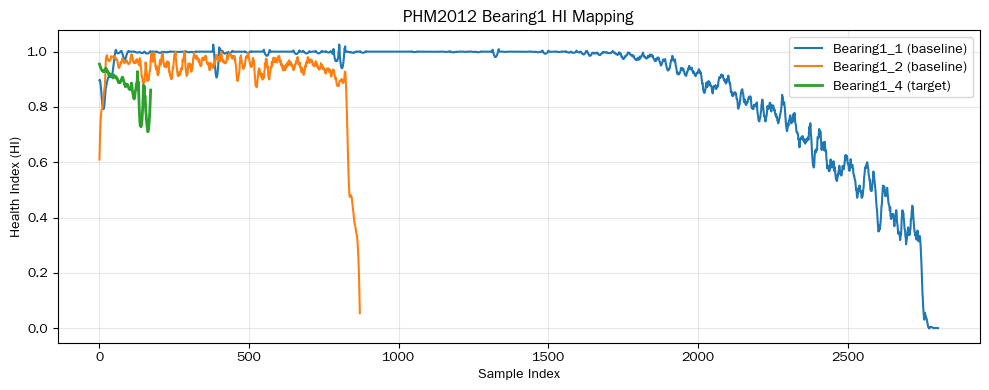

In [20]:
df23 =  process_bearing(folder="./phm-ieee-2012-data-challenge-dataset-master/Test_set/Bearing2_7")

hi_14, md_14 = compute_pca_md_hi(df23, scaler, pca, mu, inv_cov)

# --------------------------------
# 5. 可视化
# --------------------------------
plt.figure(figsize=(10, 4))
plt.plot(hi_11, label="Bearing1_1 (baseline)")
plt.plot(hi_12, label="Bearing1_2 (baseline)")
plt.plot(hi_14, label="Bearing1_4 (target)", linewidth=2)
plt.xlabel("Sample Index")
plt.ylabel("Health Index (HI)")
plt.title("PHM2012 Bearing1 HI Mapping")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()